In [102]:
import os
import json
import torch
import warnings
import matplotlib.pyplot as plt
from transformers import T5Tokenizer

warnings.filterwarnings("ignore")

def find_token_indices(tokenizer, prompt: str, target_word: str) -> list:
    """
    Algoritmo di Sliding Window Minimale per ricomporre sub-token.
    """
    tokens = tokenizer(prompt, return_tensors="pt").input_ids[0]
    target_word = target_word.strip().lower()
    
    for i in range(len(tokens)):
        for j in range(i + 1, len(tokens) + 1):
            chunk = tokenizer.decode(tokens[i:j]).strip().lower()
            
            if target_word in chunk:
                chunk_minus_first = tokenizer.decode(tokens[i+1:j]).strip().lower() if i+1 < j else ""
                chunk_minus_last = tokenizer.decode(tokens[i:j-1]).strip().lower() if i < j-1 else ""
                
                if target_word not in chunk_minus_first and target_word not in chunk_minus_last:
                    print(f"✅ Ricostruzione semantica trovata: '{chunk}' -> Indici: {list(range(i, j))}")
                    return list(range(i, j))
    return []

In [103]:
def inspect_semantic_mask(db_path: str, word_to_isolate: str, manual_tokens: list = None):
    print(f"--- Analisi Attrattore Semantico per '{word_to_isolate}' ---")
    
    # 1. Metadati e Tokenizer
    with open(os.path.join(db_path, "metadata.json"), "r") as f:
        target_prompt = json.load(f)["prompt"]
        
    print(f"Prompt originario: '{target_prompt}'")
    tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl", legacy=False, clean_up_tokenization_spaces=True)
    
    # 2. Risoluzione Indici
    if manual_tokens is not None:
        print(f"⚠️ OVERRIDE MANUALE: Utilizzo gli indici: {manual_tokens}")
        token_indices = manual_tokens
    else:
        token_indices = find_token_indices(tokenizer, target_prompt, word_to_isolate)
        
    if not token_indices:
        print(f"❌ CRITICO: Parola '{word_to_isolate}' non trovata. Prova con manual_tokens.")
        return None
    
    # 3. Estrazione e Matematica (tutto in CPU)
    attn_target = torch.load(os.path.join(db_path, "attention_maps.pt"), map_location="cpu", weights_only=True)
    layer_10 = attn_target['layer_10'] 
    
    attn_maps_list = [layer_10[0, :, :, idx].mean(dim=0) for idx in token_indices]
    attn_map = torch.clamp(torch.stack(attn_maps_list).sum(dim=0), min=0.0, max=1.0)
    
    attn_min, attn_max = attn_map.min(), attn_map.max()
    A_target = (attn_map - attn_min) / (attn_max - attn_min + 1e-8)
    
    # 4. Salvataggio per il Cluster
    A_target_flat = A_target.unsqueeze(0).unsqueeze(-1) # Diventa [1, 4096, 1]
    
    out_file = os.path.join(db_path, "A_target.pt")
    torch.save(A_target_flat, out_file)
    print(f"✅ Attrattore semantico salvato con successo in: {out_file}")
    
    # 5. Plotting (Trasformiamo [4096] in [64, 64])
    mask_2d = A_target.cpu().to(torch.float32).numpy()
    grid_size = int(mask_2d.shape[0] ** 0.5)
    mask_grid = mask_2d.reshape(grid_size, grid_size)

    plt.figure(figsize=(6, 6))
    plt.imshow(mask_grid, cmap='magma', interpolation='nearest') 
    plt.colorbar(label='Intensità Attenzione (Normalizzata)')
    plt.title(f"Attrattore: {word_to_isolate}\n(Token indici: {token_indices})", fontsize=14)
    plt.axis('off')
    plt.show()

    return A_target

TEST 1: Automazione
--- Analisi Attrattore Semantico per 'sphere' ---
Prompt originario: 'a blue sphere'
✅ Ricostruzione semantica trovata: 'sphere' -> Indici: [4]
✅ Attrattore semantico salvato con successo in: ../data/dataset_v1/a_blue_sphere/A_target.pt


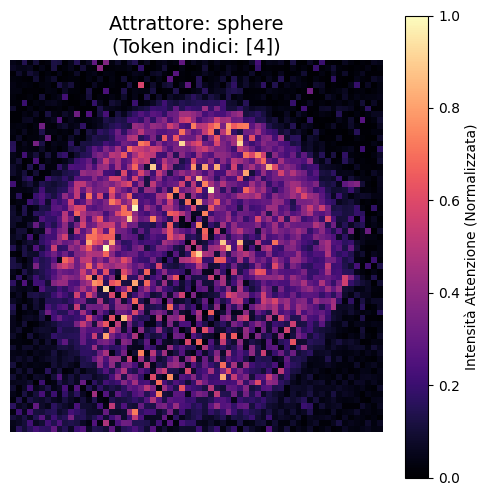


TEST 2: Il Cubo (Automatico)
--- Analisi Attrattore Semantico per 'cube' ---
Prompt originario: 'a red cube'
✅ Ricostruzione semantica trovata: 'cube' -> Indici: [3, 4]
✅ Attrattore semantico salvato con successo in: ../data/dataset_v1/a_red_cube/A_target.pt


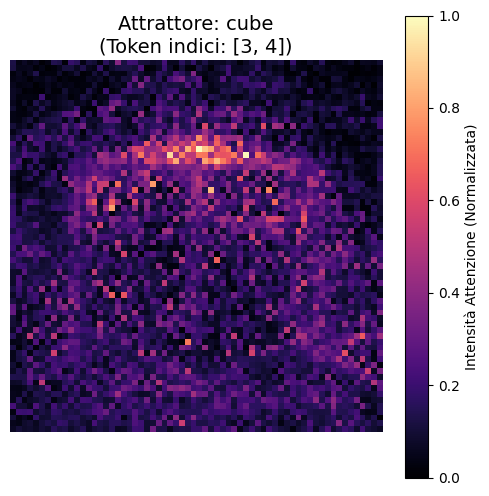


TEST 3: Forzatura Manuale
--- Analisi Attrattore Semantico per 'pyramid' ---
Prompt originario: 'a yellow pyramid'
✅ Ricostruzione semantica trovata: 'pyramid' -> Indici: [3]
✅ Attrattore semantico salvato con successo in: ../data/dataset_v1/a_yellow_pyramid/A_target.pt


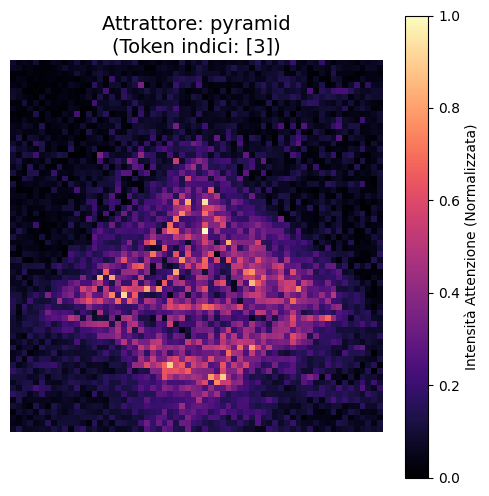

In [104]:
# Prova automatica (Slide Window)
print("TEST 1: Automazione")
A_sfera = inspect_semantic_mask(
    db_path="../data/dataset_v1/a_blue_sphere", 
    word_to_isolate="sphere"
)

#Prova con il cubo (se hai il path pronto)
print("\nTEST 2: Il Cubo (Automatico)")
A_cubo = inspect_semantic_mask(
    db_path="../data/dataset_v1/a_red_cube", 
    word_to_isolate="cube"
)

#Esempio di forzatura manuale se il tokenizer fa troppi danni
print("\nTEST 3: Forzatura Manuale")
A_forzato = inspect_semantic_mask(
    db_path="../data/dataset_v1/a_yellow_pyramid", 
    word_to_isolate="pyramid"
)

--- Estrazione Automatica Maschera Termodinamica (GMM) ---
GMM Analisi - Background Media: 11.1691, Std: 1.2757
Soglia Automatica Calcolata (Tau): 14.9961 (Norm: 0.6953)
✅ Maschera Fisica salvata in: ../data/dataset_v1/a_blue_sphere/A_materia.pt


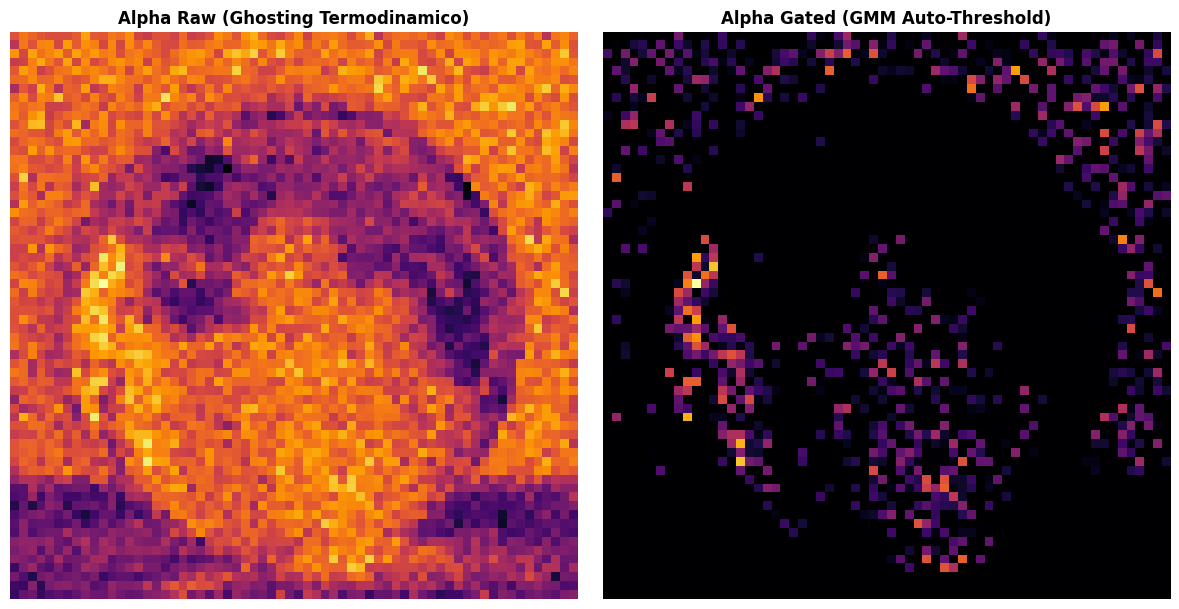

--- Estrazione Automatica Maschera Termodinamica (GMM) ---
GMM Analisi - Background Media: 14.6357, Std: 1.0064
Soglia Automatica Calcolata (Tau): 17.6550 (Norm: 0.6457)
✅ Maschera Fisica salvata in: ../data/dataset_v1/a_red_cube/A_materia.pt


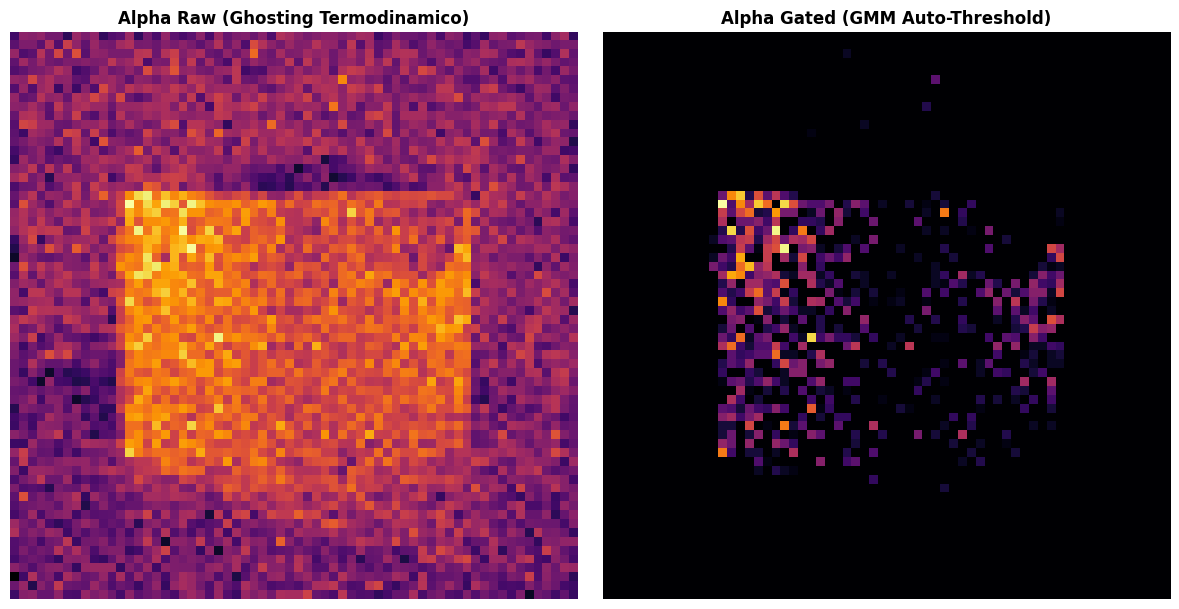

--- Estrazione Automatica Maschera Termodinamica (GMM) ---
GMM Analisi - Background Media: 12.0215, Std: 1.4335
Soglia Automatica Calcolata (Tau): 16.3220 (Norm: 0.6016)
✅ Maschera Fisica salvata in: ../data/dataset_v1/a_yellow_pyramid/A_materia.pt


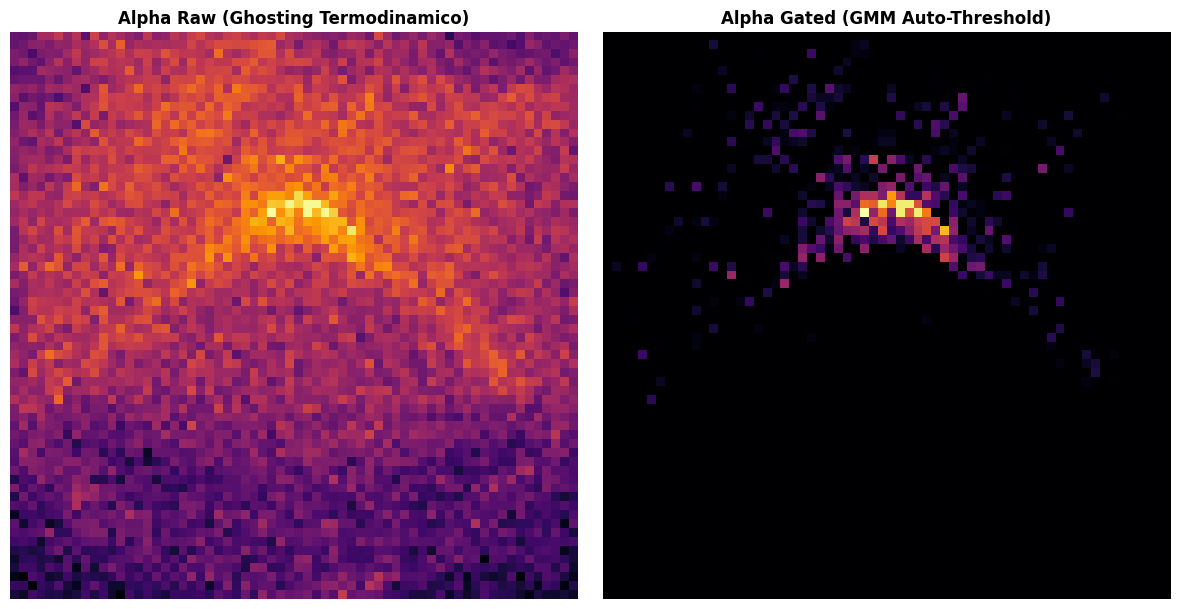

In [105]:
import numpy as np
from sklearn.mixture import GaussianMixture

def compile_thermodynamic_mask(db_path: str):
    print("--- Estrazione Automatica Maschera Termodinamica (GMM) ---")
    
    # 1. Caricamento Dati
    v0_db = torch.load(os.path.join(db_path, "v0_velocity.pt"), map_location="cpu", weights_only=True)
    
    # 2. Estrazione KPE (Kinetic Path Energy)
    v0_mag = torch.norm(v0_db, p=2, dim=-1) # Forma [1, 4096]
    mag_min, mag_max = v0_mag.min(), v0_mag.max()
    alpha_raw = (v0_mag - mag_min) / (mag_max - mag_min + 1e-8)
    
    # =================================================================
    # 3. AUTO-THRESHOLDING TRAMITE GAUSSIAN MIXTURE MODEL (GMM)
    # =================================================================
    # Trasformiamo l'energia in un array 1D per scikit-learn
    X_energy = v0_mag.to(torch.float32).view(-1, 1).numpy()
    
    # Fittiamo 2 componenti (Background vs Oggetto)
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(X_energy)
    
    # Identifichiamo quale componente è il background (quella con la media più bassa)
    bg_idx = np.argmin(gmm.means_)
    
    mu_bg = gmm.means_[bg_idx, 0]
    sigma_bg = np.sqrt(gmm.covariances_[bg_idx, 0, 0])
    
    # Soglia Automatica: 99.7% di confidenza che non sia background
    tau = mu_bg + (3.0 * sigma_bg)
    tau_norm = (tau - mag_min.item()) / (mag_max.item() - mag_min.item() + 1e-8)
    
    print(f"GMM Analisi - Background Media: {mu_bg:.4f}, Std: {sigma_bg:.4f}")
    print(f"Soglia Automatica Calcolata (Tau): {tau:.4f} (Norm: {tau_norm:.4f})")
    
    # =================================================================
    # 4. APPLICAZIONE RELU E SALVATAGGIO
    # =================================================================
    # Usiamo tau_norm calcolato dal GMM come soglia fissa
    alpha_gated = torch.clamp(alpha_raw - tau_norm, min=0.0)
    alpha_gated = alpha_gated / (1.0 - tau_norm)
    
    # Salvataggio nel DB
    A_materia = alpha_gated.unsqueeze(-1).to(torch.bfloat16) # [1, 4096, 1]
    out_file = os.path.join(db_path, "A_materia.pt")
    torch.save(A_materia, out_file)
    print(f"✅ Maschera Fisica salvata in: {out_file}")
    
    # 5. Plot di Validazione per il Capitolo 5
    grid_size = int(alpha_raw.shape[1] ** 0.5)
    img_raw = alpha_raw.to(torch.float32).view(grid_size, grid_size).numpy()
    img_gated = alpha_gated.to(torch.float32).view(grid_size, grid_size).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_raw, cmap='inferno')
    axes[0].set_title("Alpha Raw (Ghosting Termodinamico)", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_gated, cmap='inferno')
    axes[1].set_title("Alpha Gated (GMM Auto-Threshold)", fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Esegui:
compile_thermodynamic_mask("../data/dataset_v1/a_blue_sphere")
compile_thermodynamic_mask("../data/dataset_v1/a_red_cube")
compile_thermodynamic_mask("../data/dataset_v1/a_yellow_pyramid")

--- Estrazione Maschera Fisica (Otsu su Attenzione) ---
Soglia Automatica Otsu Calcolata: 0.2520
✅ Maschera Fisica (Bisturi) salvata in: ../data/dataset_v1/a_blue_sphere/A_materia.pt


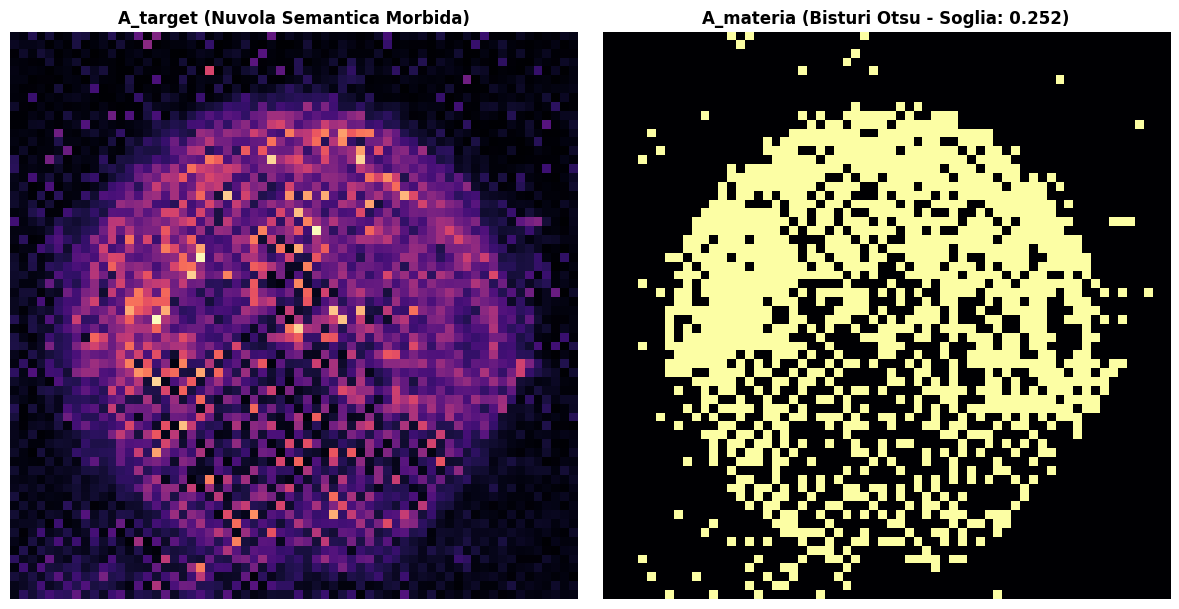

--- Estrazione Maschera Fisica (Otsu su Attenzione) ---
Soglia Automatica Otsu Calcolata: 0.2480
✅ Maschera Fisica (Bisturi) salvata in: ../data/dataset_v1/a_red_cube/A_materia.pt


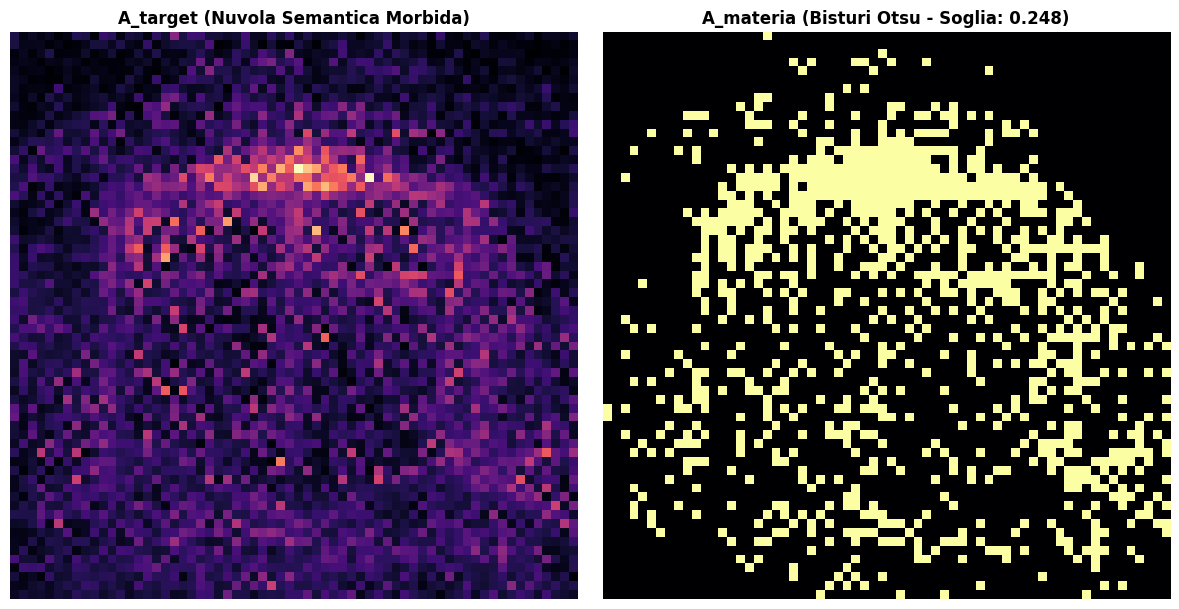

--- Estrazione Maschera Fisica (Otsu su Attenzione) ---
Soglia Automatica Otsu Calcolata: 0.2480
✅ Maschera Fisica (Bisturi) salvata in: ../data/dataset_v1/a_yellow_pyramid/A_materia.pt


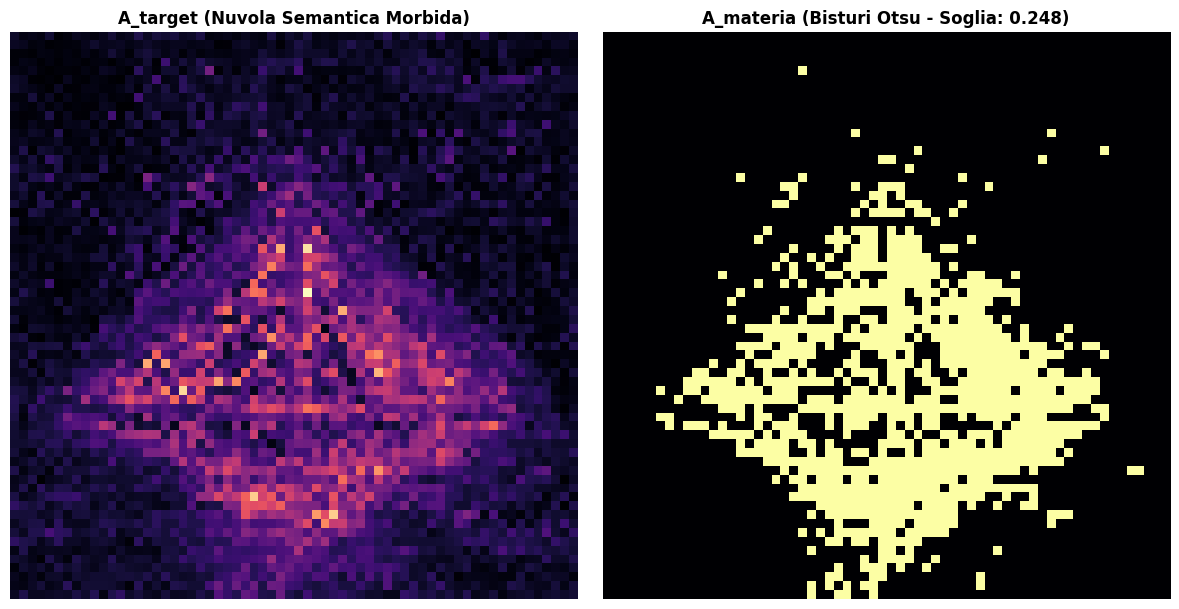

In [106]:
from skimage.filters import threshold_otsu

def compile_physical_mask_from_attention(db_path: str):
    print("--- Estrazione Maschera Fisica (Otsu su Attenzione) ---")
    
    # 1. Carichiamo la mappa di attenzione morbida (A_target) calcolata in precedenza
    A_target_path = os.path.join(db_path, "A_target.pt")
    if not os.path.exists(A_target_path):
        raise FileNotFoundError("Devi prima generare A_target.pt con lo script dell'attenzione!")
        
    A_target = torch.load(A_target_path, map_location="cpu", weights_only=True) # [1, 4096, 1]
    
    # Rimodelliamo per l'analisi dell'immagine
    grid_size = int(A_target.shape[1] ** 0.5)
    img_attention = A_target.to(torch.float32).view(grid_size, grid_size).numpy()
    
    # =================================================================
    # 2. AUTO-THRESHOLDING TRAMITE METODO DI OTSU
    # =================================================================
    # Otsu trova la soglia che separa perfettamente i pixel "accesi" da quelli "spenti"
    # basandosi sulla varianza dell'istogramma, ignorando la magnitudo vettoriale.
    otsu_threshold = threshold_otsu(img_attention)
    
    print(f"Soglia Automatica Otsu Calcolata: {otsu_threshold:.4f}")
    
    # =================================================================
    # 3. BINARIZZAZIONE E SALVATAGGIO (La Materia Netta)
    # =================================================================
    img_materia_binaria = (img_attention > otsu_threshold).astype(np.float32)
    
    # Riportiamo a tensore per FLUX
    A_materia = torch.tensor(img_materia_binaria).view(1, 4096, 1).to(torch.bfloat16)
    
    out_file = os.path.join(db_path, "A_materia.pt")
    torch.save(A_materia, out_file)
    print(f"✅ Maschera Fisica (Bisturi) salvata in: {out_file}")
    
    # =================================================================
    # 4. PLOT DI VALIDAZIONE
    # =================================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    im1 = axes[0].imshow(img_attention, cmap='magma')
    axes[0].set_title("A_target (Nuvola Semantica Morbida)", fontweight='bold')
    axes[0].axis('off')
    
    # Usiamo 'gray' per far vedere che è una maschera hard (0 o 1)
    im2 = axes[1].imshow(img_materia_binaria, cmap='inferno')
    axes[1].set_title(f"A_materia (Bisturi Otsu - Soglia: {otsu_threshold:.3f})", fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Esegui
compile_physical_mask_from_attention("../data/dataset_v1/a_blue_sphere")
compile_physical_mask_from_attention("../data/dataset_v1/a_red_cube")
compile_physical_mask_from_attention("../data/dataset_v1/a_yellow_pyramid")

--- Estrazione Maschera Fisica Soft (GMM + ReLU su Attenzione) ---
GMM Analisi Attenzione - Background Media: 0.0573, Std: 0.0414
Soglia Automatica Calcolata (Tau): 0.1816
✅ Maschera Fisica Soft salvata in: ../data/dataset_v1/a_blue_sphere/A_materia.pt


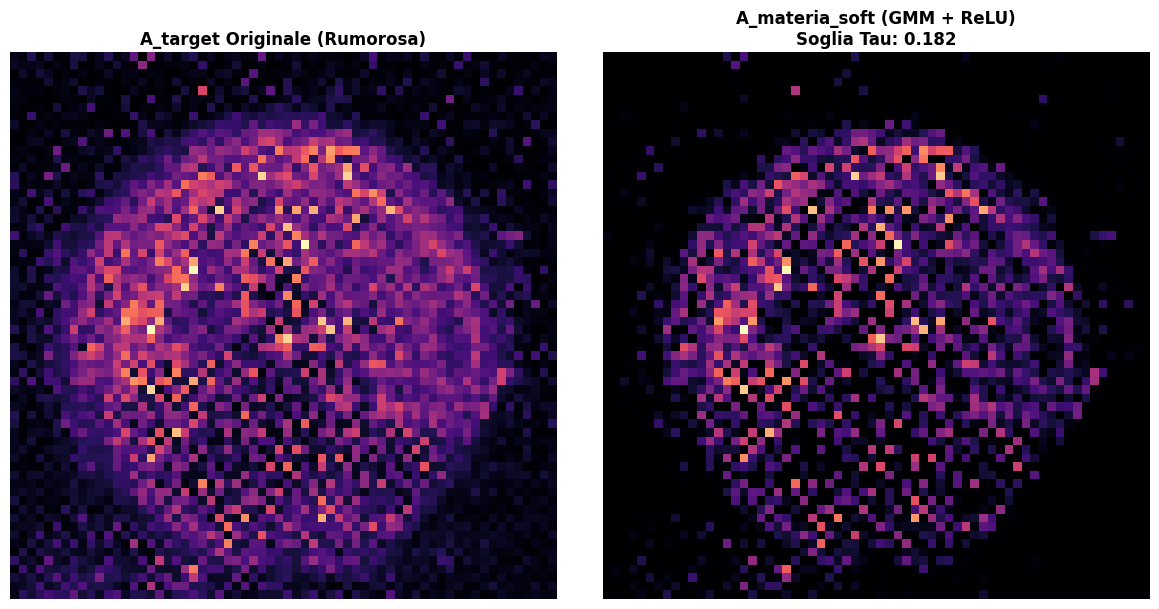

--- Estrazione Maschera Fisica Soft (GMM + ReLU su Attenzione) ---
GMM Analisi Attenzione - Background Media: 0.1297, Std: 0.0689
Soglia Automatica Calcolata (Tau): 0.3364
✅ Maschera Fisica Soft salvata in: ../data/dataset_v1/a_red_cube/A_materia.pt


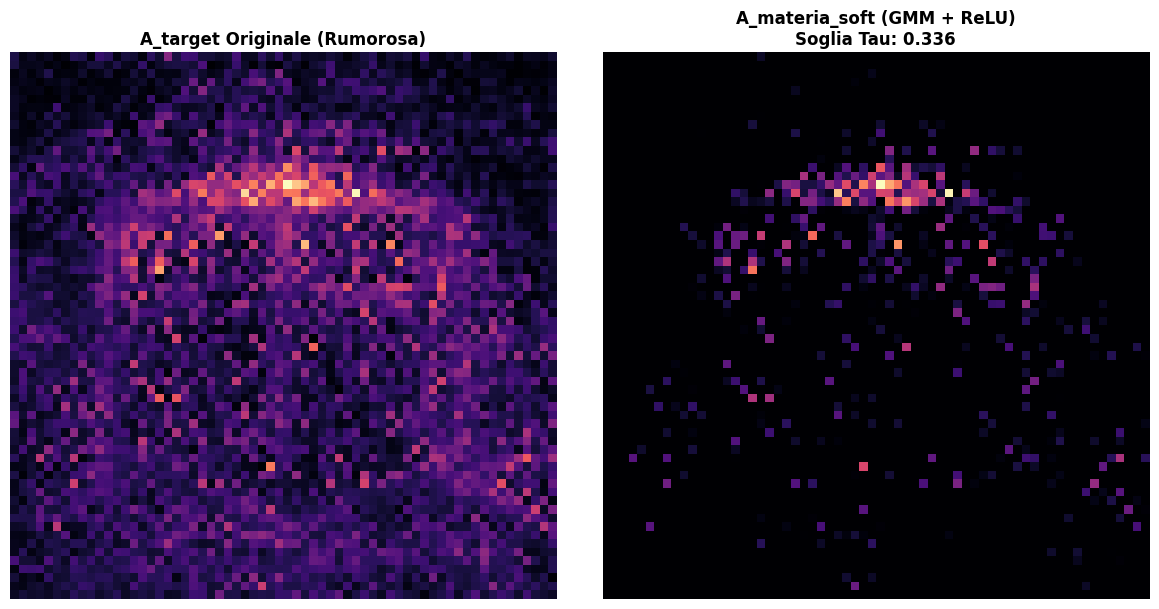

--- Estrazione Maschera Fisica Soft (GMM + ReLU su Attenzione) ---
GMM Analisi Attenzione - Background Media: 0.0856, Std: 0.0515
Soglia Automatica Calcolata (Tau): 0.2400
✅ Maschera Fisica Soft salvata in: ../data/dataset_v1/a_yellow_pyramid/A_materia.pt


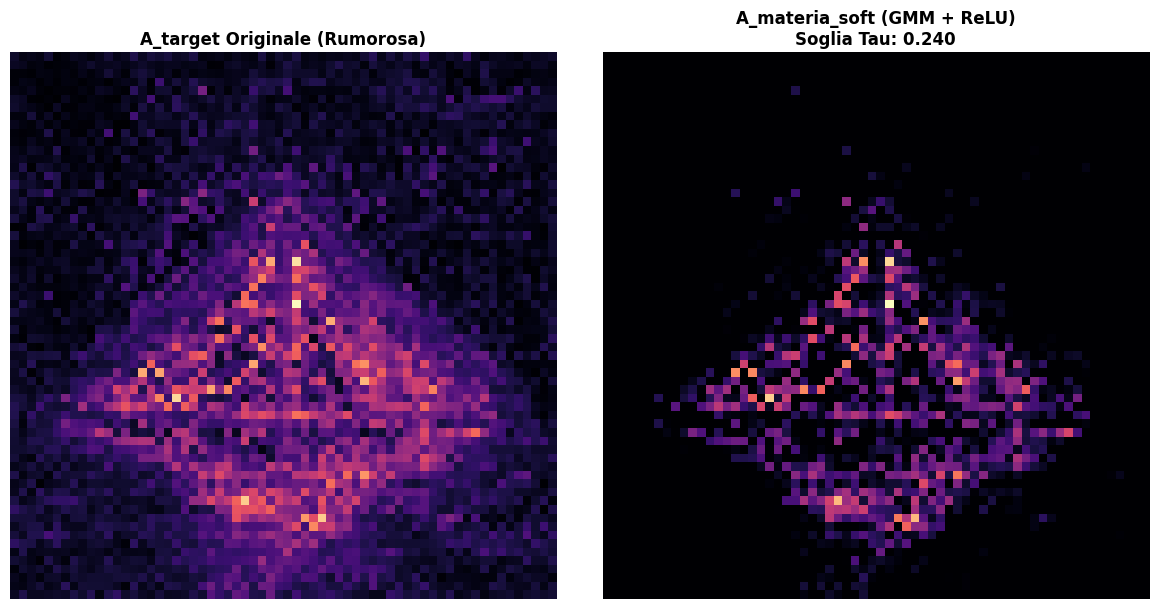

In [107]:
from sklearn.mixture import GaussianMixture

def compile_soft_physical_mask(db_path: str):
    print("--- Estrazione Maschera Fisica Soft (GMM + ReLU su Attenzione) ---")
    
    # 1. Carichiamo l'Attenzione Morbida
    A_target_path = os.path.join(db_path, "A_target.pt")
    if not os.path.exists(A_target_path):
        raise FileNotFoundError("Manca A_target.pt!")
        
    A_target = torch.load(A_target_path, map_location="cpu", weights_only=True) # [1, 4096, 1]
    
    # =================================================================
    # 2. AUTO-THRESHOLDING TRAMITE GMM SULL'ATTENZIONE
    # =================================================================
    # Usiamo il GMM per trovare la distribuzione del rumore di fondo dell'attenzione
    X_attn = A_target.to(torch.float32).view(-1, 1).numpy()
    
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(X_attn)
    
    # Il background è la componente con la media più bassa
    bg_idx = np.argmin(gmm.means_)
    mu_bg = gmm.means_[bg_idx, 0]
    sigma_bg = np.sqrt(gmm.covariances_[bg_idx, 0, 0])
    
    # Soglia: Tagliamo via il 99.7% del rumore semantico di fondo
    tau = mu_bg + (3.0 * sigma_bg)
    print(f"GMM Analisi Attenzione - Background Media: {mu_bg:.4f}, Std: {sigma_bg:.4f}")
    print(f"Soglia Automatica Calcolata (Tau): {tau:.4f}")
    
    # =================================================================
    # 3. LA TUA FORMULA: RELU TRASLATA E RICALIBRATA (Soft Gating)
    # =================================================================
    A_materia_soft = torch.clamp(A_target - tau, min=0.0)
    A_materia_soft = A_materia_soft / (1.0 - tau) # Ricalibrazione per far toccare 1.0 al picco
    
    # Salvataggio nel DB
    out_file = os.path.join(db_path, "A_materia.pt")
    torch.save(A_materia_soft.to(torch.bfloat16), out_file)
    print(f"✅ Maschera Fisica Soft salvata in: {out_file}")
    
    # =================================================================
    # 4. PLOT DI VALIDAZIONE
    # =================================================================
    grid_size = int(A_target.shape[1] ** 0.5)
    img_raw = A_target.to(torch.float32).view(grid_size, grid_size).numpy()
    img_soft = A_materia_soft.to(torch.float32).view(grid_size, grid_size).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(img_raw, cmap='magma', vmin=0, vmax=1)
    axes[0].set_title("A_target Originale (Rumorosa)", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_soft, cmap='magma', vmin=0, vmax=1)
    axes[1].set_title(f"A_materia_soft (GMM + ReLU)\nSoglia Tau: {tau:.3f}", fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

compile_soft_physical_mask("../data/dataset_v1/a_blue_sphere")
compile_soft_physical_mask("../data/dataset_v1/a_red_cube")
compile_soft_physical_mask("../data/dataset_v1/a_yellow_pyramid")

--- Estrazione Maschera Fisica Parametrica (ReLU su Attenzione, k=0.0) ---
Statistiche Attenzione -> Media: 0.1807, Std: 0.1299
Soglia Calcolata (Tau): 0.1807 con k=0.0
✅ Maschera Fisica Parametrica salvata in: ../data/dataset_v1/a_red_cube/A_materia.pt


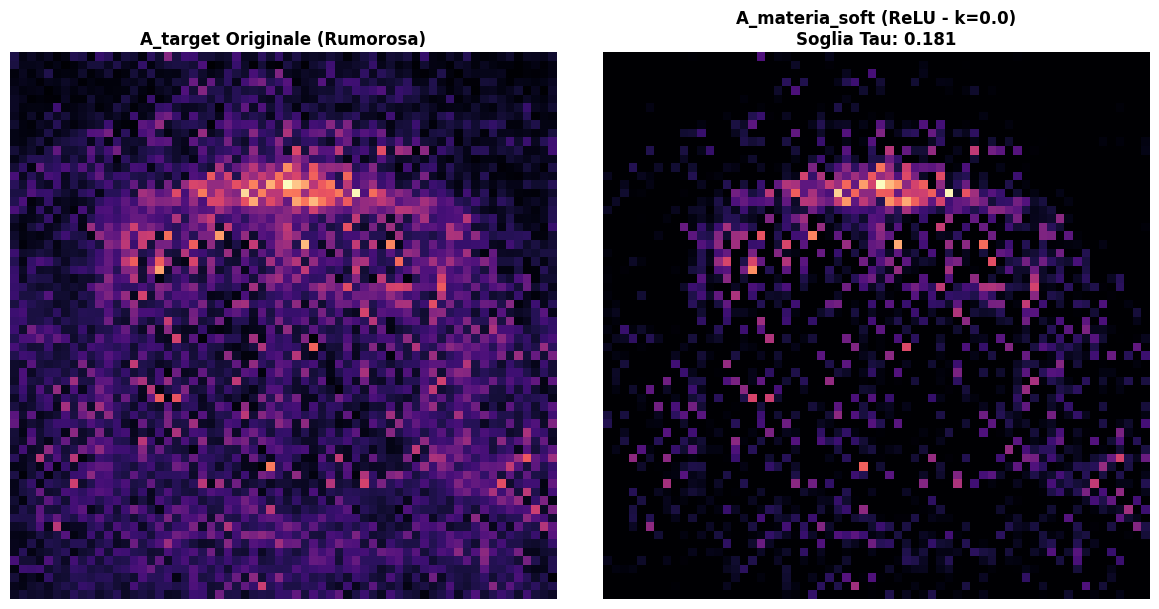

--- Estrazione Maschera Fisica Parametrica (ReLU su Attenzione, k=0.0) ---
Statistiche Attenzione -> Media: 0.1934, Std: 0.1748
Soglia Calcolata (Tau): 0.1934 con k=0.0
✅ Maschera Fisica Parametrica salvata in: ../data/dataset_v1/a_blue_sphere/A_materia.pt


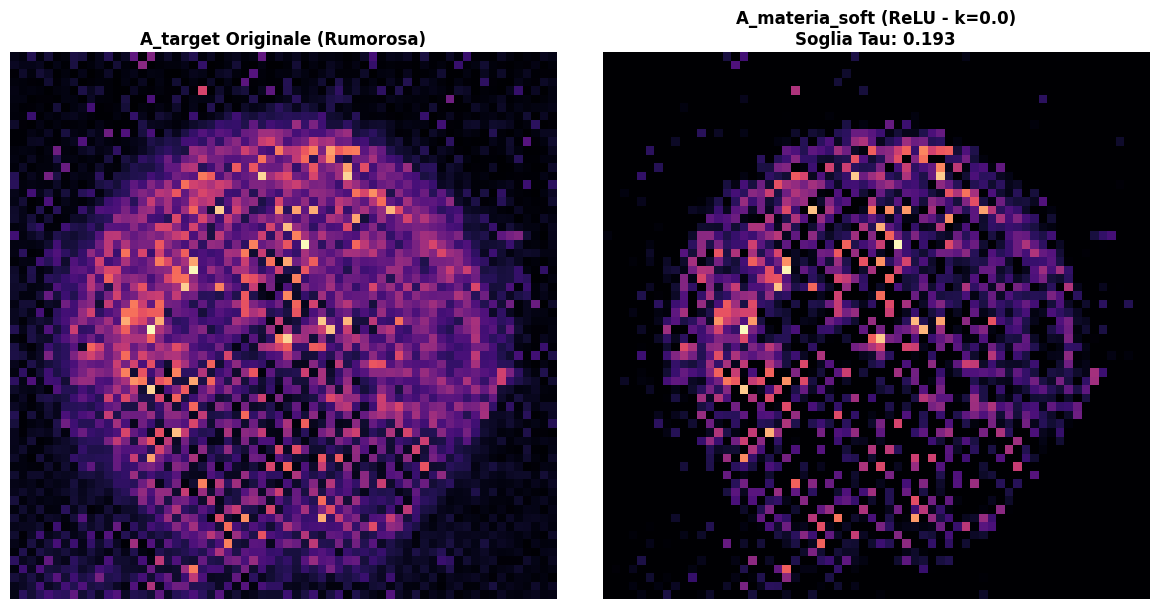

--- Estrazione Maschera Fisica Parametrica (ReLU su Attenzione, k=0.0) ---
Statistiche Attenzione -> Media: 0.1631, Std: 0.1465
Soglia Calcolata (Tau): 0.1631 con k=0.0
✅ Maschera Fisica Parametrica salvata in: ../data/dataset_v1/a_yellow_pyramid/A_materia.pt


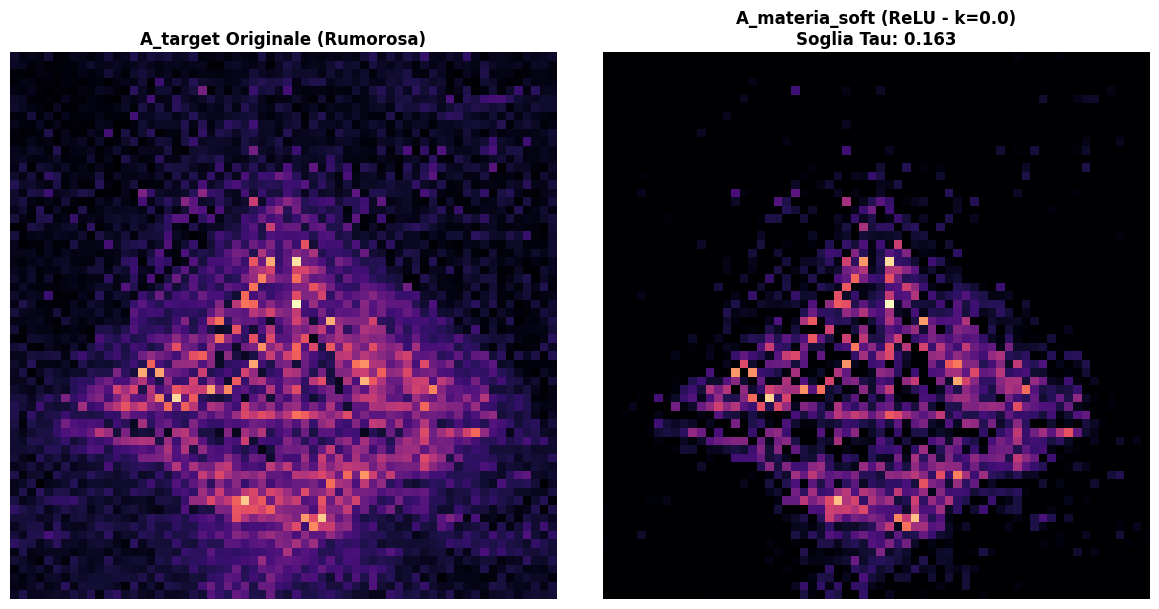

In [108]:
def compile_parametric_soft_mask(db_path: str, k: float = 0.00):
    print(f"--- Estrazione Maschera Fisica Parametrica (ReLU su Attenzione, k={k}) ---")
    
    # 1. Carichiamo l'Attenzione Morbida (La verità semantica)
    A_target_path = os.path.join(db_path, "A_target.pt")
    if not os.path.exists(A_target_path):
        raise FileNotFoundError("Manca A_target.pt!")
        
    # A_target ha già valori in [0, 1]
    A_target = torch.load(A_target_path, map_location="cpu", weights_only=True) # [1, 4096, 1]
    
    # =================================================================
    # 2. STATISTICA GLOBALE E SOGLIA MANUALE
    # =================================================================
    mu = A_target.mean()
    sigma = A_target.std()
    
    # La tua barriera termodinamica parametrica
    tau = mu + (k * sigma)
    
    print(f"Statistiche Attenzione -> Media: {mu.item():.4f}, Std: {sigma.item():.4f}")
    print(f"Soglia Calcolata (Tau): {tau.item():.4f} con k={k}")
    
    # =================================================================
    # 3. LA TUA FORMULA: RELU TRASLATA E RICALIBRATA (Soft Gating)
    # =================================================================
    # max(0, A - tau)
    A_materia_soft = torch.clamp(A_target - tau, min=0.0)
    
    # Ricalibrazione per far toccare 1.0 al picco dell'oggetto
    # Evitiamo divisioni per zero o valori negativi se tau è troppo alto
    scale_factor = 1.0 - tau.item()
    if scale_factor <= 0.01:
        print("⚠️ ATTENZIONE: Il valore di k è così alto che distrugge l'intero tensore. Abbassalo.")
        scale_factor = 0.01
        
    A_materia_soft = A_materia_soft / scale_factor
    
    # Sicurezza: non superare mai l'1.0 puro
    A_materia_soft = torch.clamp(A_materia_soft, max=1.0)
    
    # Salvataggio nel DB
    out_file = os.path.join(db_path, "A_materia.pt")
    torch.save(A_materia_soft.to(torch.bfloat16), out_file)
    print(f"✅ Maschera Fisica Parametrica salvata in: {out_file}")
    
    # =================================================================
    # 4. PLOT DI VALIDAZIONE
    # =================================================================
    grid_size = int(A_target.shape[1] ** 0.5)
    img_raw = A_target.to(torch.float32).view(grid_size, grid_size).numpy()
    img_soft = A_materia_soft.to(torch.float32).view(grid_size, grid_size).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # vmin=0 e vmax=1 ci assicurano che i colori siano coerenti tra i due grafici
    axes[0].imshow(img_raw, cmap='magma', vmin=0, vmax=1)
    axes[0].set_title("A_target Originale (Rumorosa)", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_soft, cmap='magma', vmin=0, vmax=1)
    axes[1].set_title(f"A_materia_soft (ReLU - k={k})\nSoglia Tau: {tau:.3f}", fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


# Esegui provando diversi valori di k
compile_parametric_soft_mask("../data/dataset_v1/a_red_cube")
compile_parametric_soft_mask("../data/dataset_v1/a_blue_sphere")
compile_parametric_soft_mask("../data/dataset_v1/a_yellow_pyramid")